In [1]:
import pandas as pd
from pathlib import Path

# Read a CSV file into a DataFrame and return None if loading fails.
def read_csv_to_dataframe(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as exc:
        print(f"An error occurred while reading {file_path}: {exc}")
        return None

In [2]:
import sys

project_root = Path(r'C:\Users\Divyeh\OneDrive\Desktop\ML_IP\NOVA_Food_Processing')
code_files_path = project_root / 'Code_Files'

for path in (project_root, code_files_path):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

data_path = project_root / 'Data' / 'Numerical' / 'Data' / '65_Nutrients_Data.csv'
data = read_csv_to_dataframe(data_path)

path_smote = project_root / 'models' / 'numerical_65_rf' / 'smote'
path_strat = project_root / 'models' / 'numerical_65_rf' / 'strat'
path_smote_strat = project_root / 'models' / 'numerical_65_rf' / 'smote_strat'
path_smote.mkdir(parents=True, exist_ok=True)
path_strat.mkdir(parents=True, exist_ok=True)
path_smote_strat.mkdir(parents=True, exist_ok=True)

print('Data and output folders are ready.')

Data and output folders are ready.


In [3]:
from sklearn.model_selection import train_test_split

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (2376, 65), Test size: (594, 65)


In [4]:
from sklearn.ensemble import RandomForestClassifier
from Utility_Codes.Utility_model_training import (
    evaluate_classifier_with_stratified_smote,
    evaluate_classifier_with_stratified_kfold,
    evaluate_classifier_with_kfold_smote,
)

rf = RandomForestClassifier(n_estimators=200, random_state=42)

evaluate_classifier_with_stratified_smote(
    X_train, y_train, X_test, y_test, rf,
    num_folds=5, save_path=str(path_smote_strat),
    model_name='rf_numerical_65_smote_stratified'
)
evaluate_classifier_with_stratified_kfold(
    X_train, y_train, X_test, y_test, rf,
    num_folds=5, save_path=str(path_strat),
    model_name='rf_numerical_65_stratified'
)
evaluate_classifier_with_kfold_smote(
    X_train, y_train, X_test, y_test, rf,
    num_folds=5, save_path=str(path_smote),
    model_name='rf_numerical_65_smote'
)

Average Accuracy Val K-Fold: 91.2459
Average Accuracy Train K-Fold: 99.8928
Average MCC Val K-Fold: 0.8116
Average MCC Train K-Fold: 0.9986
Average F1 Score Val K-Fold: 0.9124
Average F1 Score Train K-Fold: 0.9989
Average Precision Val K-Fold: 0.9153
Average Precision Train K-Fold: 0.9989
Average Recall Val K-Fold: 0.9125
Average Recall Train K-Fold: 0.9989
Accuracy Test: 90.24%
MCC Test: 0.7839
F1 Score Test: 0.9012
Precision Test: 0.9010
Recall Test: 0.9024
Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.79      0.77        68
           2       0.90      0.82      0.86        11
           3       0.80      0.71      0.75        93
           4       0.95      0.96      0.96       422

    accuracy                           0.90       594
   macro avg       0.85      0.82      0.83       594
weighted avg       0.90      0.90      0.90       594

Confusion Matrix Test:
[[ 54   0   9   5]
 [  0   9   0   2]
 [ 12   0  66  15

{'train_scores': [0.9990802060338484,
  0.9985130111524163,
  0.9992652461425422,
  0.9988978692138134,
  0.9988755622188905],
 'val_scores': [0.9264705882352942,
  0.911578947368421,
  0.8926315789473684,
  0.9242105263157895,
  0.9178947368421052]}

Average Accuracy Val K-Fold: 91.2459
Average Accuracy Train K-Fold: 99.8928
Average MCC Val K-Fold: 0.8116
Average MCC Train K-Fold: 0.9986
Average F1 Score Val K-Fold: 0.9124
Average F1 Score Train K-Fold: 0.9989
Average Precision Val K-Fold: 0.9153
Average Precision Train K-Fold: 0.9989
Average Recall Val K-Fold: 0.9125
Average Recall Train K-Fold: 0.9989
Accuracy Test: 90.24%
MCC Test: 0.7839
F1 Score Test: 0.9012
Precision Test: 0.9010
Recall Test: 0.9024
Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.79      0.77        68
           2       0.90      0.82      0.86        11
           3       0.80      0.71      0.75        93
           4       0.95      0.96      0.96       422

    accuracy                           0.90       594
   macro avg       0.85      0.82      0.83       594
weighted avg       0.90      0.90      0.90       594

Confusion Matrix Test:
[[ 54   0   9   5]
 [  0   9   0   2]
 [ 12   0  66  15

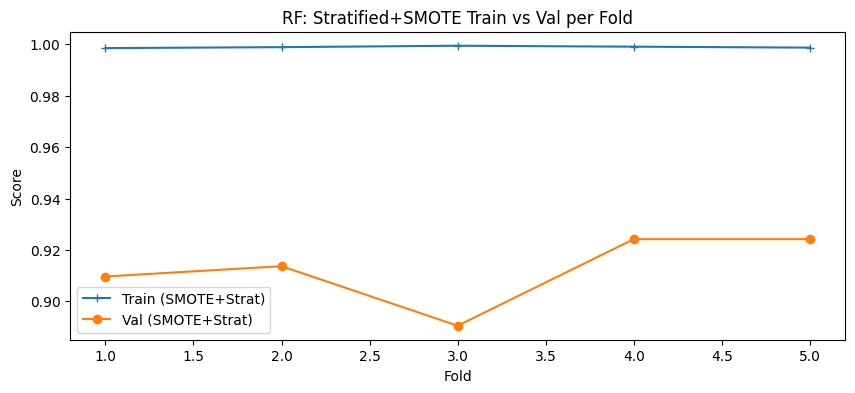

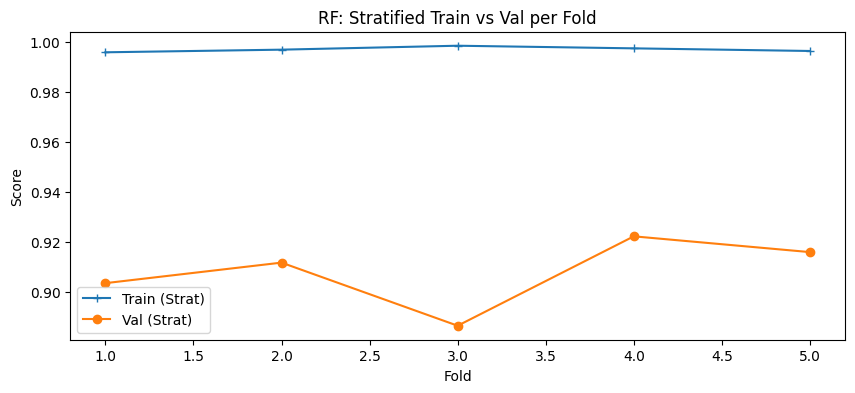

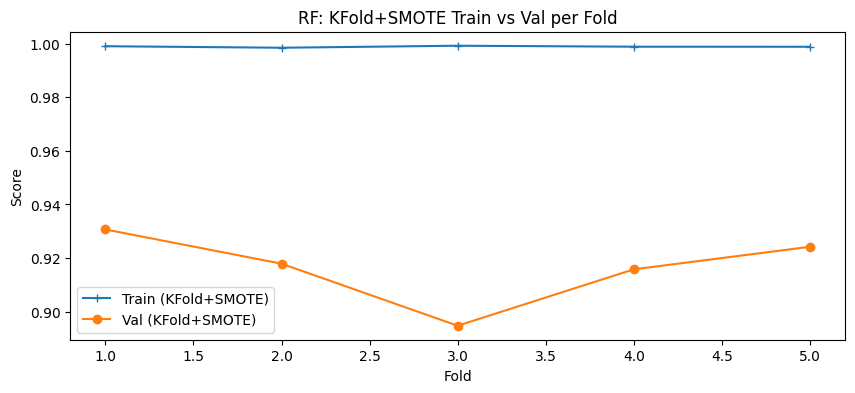

In [5]:
# Explicitly run evaluation but capture fold scores without plotting inside the utility
from Utility_Codes.Utility_model_training import (
    evaluate_classifier_with_stratified_smote,
    evaluate_classifier_with_stratified_kfold,
    evaluate_classifier_with_kfold_smote,
)

scores_smote_strat = evaluate_classifier_with_stratified_smote(
    X_train, y_train, X_test, y_test, rf,
    num_folds=5, save_path=str(path_smote_strat),
    model_name='rf_numerical_65_smote_stratified', plot_scores=False
)
scores_strat = evaluate_classifier_with_stratified_kfold(
    X_train, y_train, X_test, y_test, rf,
    num_folds=5, save_path=str(path_strat),
    model_name='rf_numerical_65_stratified', plot_scores=False
)
scores_smote = evaluate_classifier_with_kfold_smote(
    X_train, y_train, X_test, y_test, rf,
    num_folds=5, save_path=str(path_smote),
    model_name='rf_numerical_65_smote', plot_scores=False
)

# Plot the fold-wise train/validation curves inline for quick inspection
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(scores_smote_strat['train_scores']) + 1), scores_smote_strat['train_scores'], label='Train (SMOTE+Strat)', marker='+')
plt.plot(range(1, len(scores_smote_strat['val_scores']) + 1), scores_smote_strat['val_scores'], label='Val (SMOTE+Strat)', marker='o')
plt.title('RF: Stratified+SMOTE Train vs Val per Fold')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(scores_strat['train_scores']) + 1), scores_strat['train_scores'], label='Train (Strat)', marker='+')
plt.plot(range(1, len(scores_strat['val_scores']) + 1), scores_strat['val_scores'], label='Val (Strat)', marker='o')
plt.title('RF: Stratified Train vs Val per Fold')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(scores_smote['train_scores']) + 1), scores_smote['train_scores'], label='Train (KFold+SMOTE)', marker='+')
plt.plot(range(1, len(scores_smote['val_scores']) + 1), scores_smote['val_scores'], label='Val (KFold+SMOTE)', marker='o')
plt.title('RF: KFold+SMOTE Train vs Val per Fold')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.legend()
plt.show()

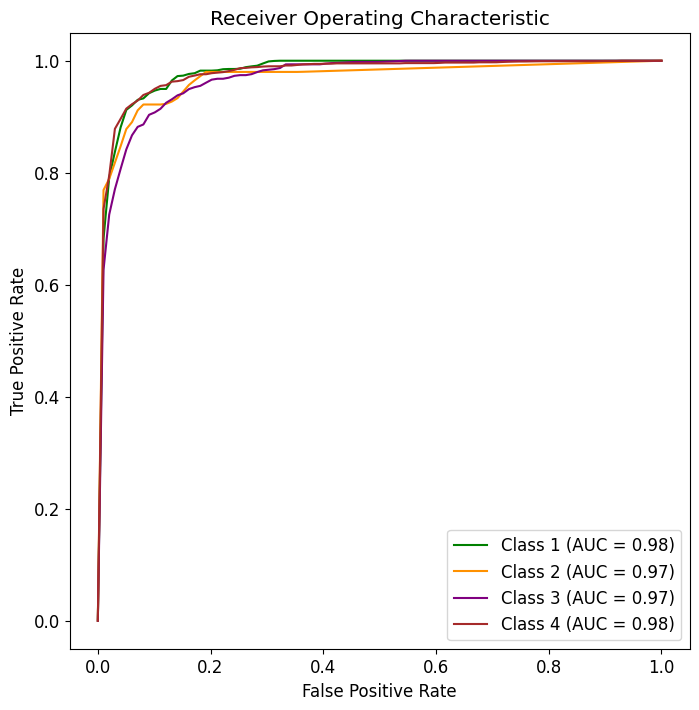

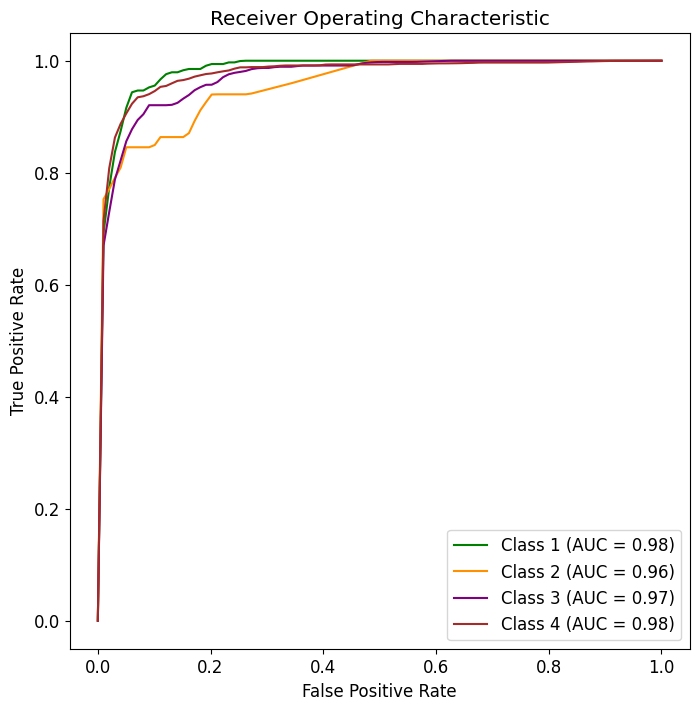

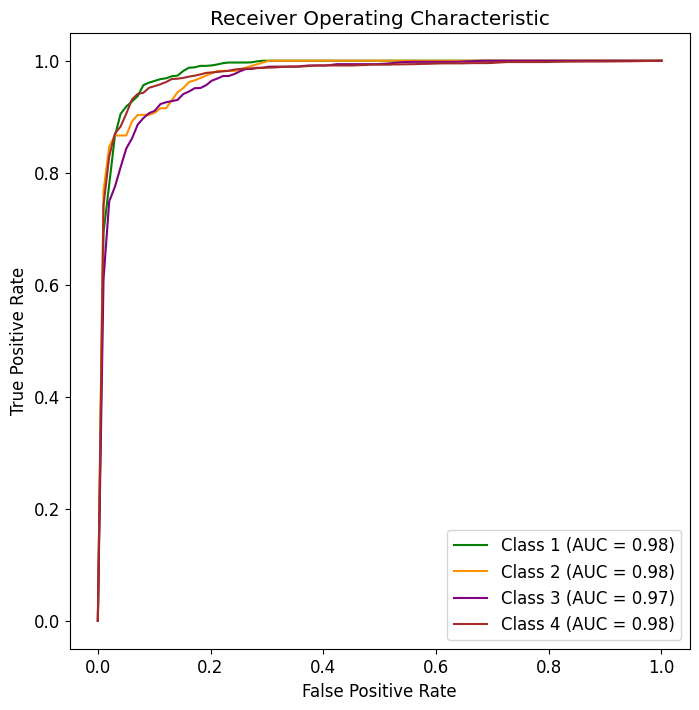

In [6]:
from Utility_ROC_Curves import (
    plot_roc_curves_multiclass_smote_strat,
    plot_roc_curves_multiclass_strat,
    plot_roc_curves_multiclass_smote,
)

path_strat_ROC = project_root / 'models' / 'numerical_65_rf' / 'strat' / 'ROC_Curves'
path_smote_strat_ROC = project_root / 'models' / 'numerical_65_rf' / 'smote_strat' / 'ROC_Curves'
path_smote_ROC = project_root / 'models' / 'numerical_65_rf' / 'smote' / 'ROC_Curves'

# 1. Stratified baseline
plot_roc_curves_multiclass_strat(
    rf, X, y, n_splits=5, save_folder=str(path_strat_ROC),
    model_name='rf_numerical_65_stratified'
)
# 2. Stratified + SMOTE
plot_roc_curves_multiclass_smote_strat(
    rf, X, y, n_splits=5, save_folder=str(path_smote_strat_ROC),
    model_name='rf_numerical_65_smote_stratified'
)
# 3. KFold + SMOTE
plot_roc_curves_multiclass_smote(
    rf, X, y, n_splits=5, save_folder=str(path_smote_ROC),
    model_name='rf_numerical_65_smote'
)

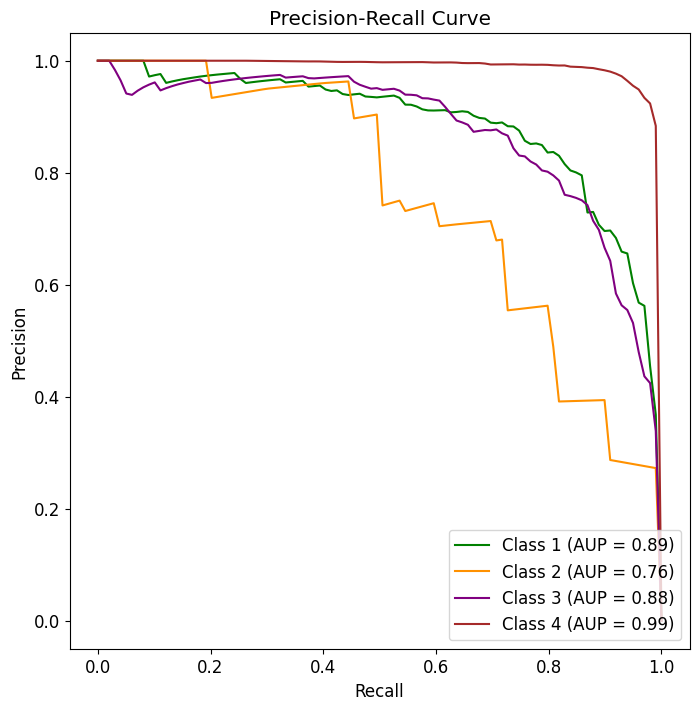

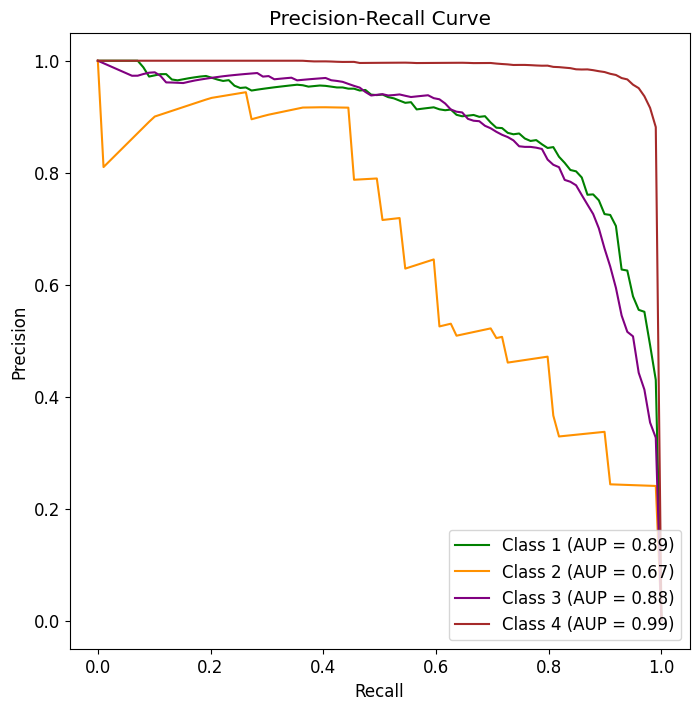

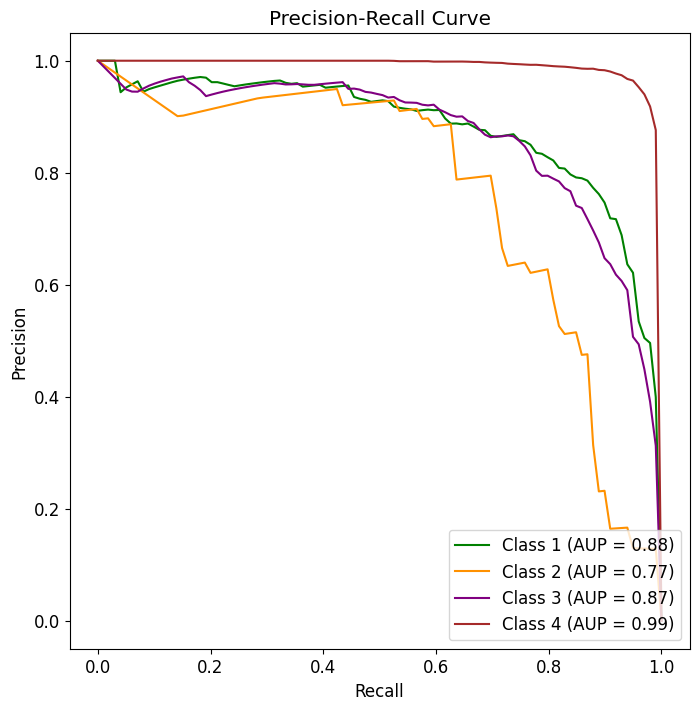

In [7]:
from Utility_AUPRC import (
    plot_pr_curves_multiclass_strat,
    plot_pr_curves_multiclass_strat_smote,
    plot_pr_curves_multiclass_kfold_smote,
)

path_strat_PR = project_root / 'models' / 'numerical_65_rf' / 'strat' / 'PR_Curves'
path_smote_strat_PR = project_root / 'models' / 'numerical_65_rf' / 'smote_strat' / 'PR_Curves'
path_smote_PR = project_root / 'models' / 'numerical_65_rf' / 'smote' / 'PR_Curves'

# 1. Stratified baseline
plot_pr_curves_multiclass_strat(
    rf, X, y, n_splits=5, save_folder=str(path_strat_PR),
    model_name='rf_numerical_65_stratified'
)
# 2. Stratified + SMOTE
plot_pr_curves_multiclass_strat_smote(
    rf, X, y, n_splits=5, save_folder=str(path_smote_strat_PR),
    model_name='rf_numerical_65_smote_stratified'
)
# 3. KFold + SMOTE
plot_pr_curves_multiclass_kfold_smote(
    rf, X, y, n_splits=5, save_folder=str(path_smote_PR),
    model_name='rf_numerical_65_smote'
)